# **<span style="color:#66CCFF">Answer Key:**</span> 6th-Order Expansion Results
#### Author: Lauren Frank



In [81]:
import sympy as sp
import json
import copy

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Define System Variables

In [82]:
#Define System Variables
w, t, a, f, E, C_11, C_13, C_22, C_24, C_3, C_4, c_b = sp.symbols(r'\omega t a f E C_{11}^{S} C_{13}^{S} C_{22}^{S} C_{24}^{S} C_{3}^{S} C_{4}^{S} c^{b}',real=True)
sp.init_printing(use_unicode=True) #prints terms in series using a human-readable format

#Sympy Fraction
one_half = sp.Rational(1, 2) #needed to avoid solutions having decimal notation

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; b. Filtering Functions

In [83]:
def filter_series(terms_list, N, wt_dict):
    
    '''
    Modifies an ordered set of terms by deleting h.o.t. (i.e O(term) > O(∆E^N) and j > N)
    
    Args:
        terms_list (list): ordered terms from expanded series
        N (int): highest ordered harmonic terms to keep (e.g. up to 4th order... N = 4)
        wt_dict (dict): dictionary where the keys are the sympy representations of each concentration coefficient
                        (e.g. C_11, C_3, etc.) and the values are the weights (∆E^k) of the different harmonics (e.g. C_11 = 1, C_3 = 3)
    
    Return:
        res (list): list of filtered terms
    '''
    
    res = []
    for term in terms_list:
        
        #Dictionary with base numbers as keys and exponents as values (e.g. C_11^2 * C_24^3 * a^2 ==> keys: C_11, C_24, a; values: 2, 3, 2)
        powers_dict = term.as_powers_dict()
        exp_key = sp.exp(1) #key --> sympy representation of exponential base e
        harmonic = -1
        
        if exp_key in powers_dict:

            #Harmonic Number of Exponential
            harmonic = int(abs(powers_dict[exp_key] / (sp.I * t * w))) #determines the harmonic number j of each term

            if harmonic > N:
                continue #removes terms with exponentials greater than n (j > n)
        
        #Calculates the Total ∆E^k of each Term
        pow = 0
        for key in powers_dict:
            temp_key = str(key) #converts Sympy representation of variable to explicit string
            if temp_key in wt_dict:
                wt = wt_dict[temp_key] #∆E^k weight (e.g C_24 ==> wt = 4)
                exp = powers_dict[key] #Raised Exponent of Term (e.g. C_24^3 ==> exp = 3)
                pow += wt * exp #∆E^(k_1*exp_1) * #∆E^(k_2*exp_2) * .... #∆E^(k_i*exp_i)  ==>  k power = (k_1*exp_1) + (k_2*exp_2) + ... (k_i*exp_i)              
        if pow <= N:
            res.append(term) #Adds terms only if the summed exponents (k) is less than / equal to 'N'  
    
    return res

In [84]:
def sort_harmonics(filtered_terms):
        
    '''
    Sorts the different terms into respective harmonic bins via a dictionary [keys are const, 1, 2, 3, ...; values are series of terms]
    
    Args:
        filtered_terms (list): list containing the terms that have been filtered
    
    Return:
        res_dict (dict): dictionary containing the sorted terms with exponentials still attatched
    
    '''
    
    res_dict = {"const":[]}
    for term in filtered_terms:
        
        #Dictionary with base numbers as keys and exponents as values (e.g. C_11^2 * C_24^3 * a^2 ==> keys: C_11, C_24, a; values: 2, 3, 2)
        powers_dict = term.as_powers_dict()
        exp_key = sp.exp(1) #key --> sympy representation of exponential base e
        
        if exp_key in powers_dict:

            harmonic = int(abs(sp.simplify(powers_dict[exp_key] / (sp.I * t * w)))) #determines the harmonic number j of each term

            if harmonic in res_dict:
                val = res_dict[harmonic]
                res_dict[harmonic] = val + [term] #adds term to existing harmonic series
            else:
                res_dict[harmonic] = [term] #creates first term in new harmoinc series
        else:
            res_dict["const"] += [term] #adds to const bin if no harmonic contribution detected
                
    return res_dict
        

In [85]:
def get_coeff(terms,harm):
    
    '''
    Extracts the coefficients of each harmonic by combining (+) and (-) exponent pairs and factoring out the constants in front of each into a list
    
    Args:
        terms (list): specific list of harmonic terms from res_dict at a single harmonic
        harm (int): harmonic number that alligns with the provided terms
    
    Return:
        coeff_list (list): list of coefficients for the specified harmonic termed list
    
    '''
    
    coeff_list= []
    for term in terms:
        powers_dict = term.as_powers_dict()
        exp_key = sp.exp(1)
        exp = int((sp.simplify(powers_dict[exp_key] / (harm * sp.I * t * w))))
        coeff = term / sp.exp(harm * exp * sp.I * t * w)
        coeff_list.append(coeff)
    coeff_list = coeff_list[::2]
    
    return coeff_list## Expansion + Filtering

In [86]:
def sep_coeff(coeff_list, wt_dict):

    '''
    Creates a dictionary from a coeff_list, where the keys are the different total powers, k,
    of the terms and the values are lists containing the terms with those total powers. 
    This is used to extract/seperate the different contribution terms from a single harmonic 
    (e.g first harmonic - extract its first order (∆E^1) and third order (∆E^3) contributions separately).
    
    Args:
        coeff_list (list): list of coefficients for a single harmonic (output of get_coeff) (e.g )
        wt_dict (dict): dictionary where the keys are the differnt variables in the system 
        (e.g. C_3, C_3, etc.) and the values are the weights (∆E^w) of the different harmonics (e.g. C_3 = 3)
    
    Return:
        res_dict (dict): dictionary containing the terms of the coeff_list separated by keys 
        representing the harmonic totals
    
    '''
    
    res_dict = {}
    for coeff in coeff_list:
        
        powers_dict = coeff.as_powers_dict()
        pow = 0
        for key in powers_dict:
            temp_key = str(key)
            if temp_key in wt_dict:
                wt = wt_dict[temp_key]
                exp = powers_dict[key]
                pow += wt * exp
                
        if pow not in res_dict:
            res_dict[pow] = [coeff]
        else:
            val = res_dict[pow]
            res_dict[pow] = val + [coeff]    
            
    return res_dict
        

In [87]:
def get_dict(filepath,variables_dict):
    
    '''
    Creates a harmonic dictionary from a .json file and converts strings to correct sympy representation
    
    Args:
        filepath (str): filepath to .json file containing the higher-order term dictionary
        variables_dict (dict): dictionary where the keys are print representations for a set of Sympy variables
        (e.g. 'C_12', 'C_33', etc.) and the values are the associated Sympy variables (e.g. C_33 = sp.symbol(r'C_3',real=True))
    
    Return:
        loaded_data_sympy (dict): resulting harmonic dictionary
    '''
    
    with open(filepath, "r") as file:
        loaded_data = json.load(file)
        loaded_data_sympy = {key: sp.sympify(expr,locals=variables_dict) for key, expr in loaded_data.items()}
    return loaded_data_sympy

In [88]:
def sub_repr(harmonic_dict,latex_map):
    '''
    Substitutes in new sympy variables with correct latex string representation.
    
    Args:
        harmonic_dict (dict): harmonic_dictionary returned by get_dict() containing incorrect Sympy variable represenations
        latex_map (dict): dictionary where the keys are Sympy variables used in the harmonic_dict input
        (e.g. C_12_t = sp.symbol(r'C_12',real=True)) and the values are the correctly latex-formatted Sympy variables (e.g. C_12 = sp.symbol(r'C_{12}^{S},real=True))
    
    Return:
        harmonic_dict_copy (dict): new harmonic dictionary containing the correctly formatted Sympy variables
    '''
    
    harmonic_dict_copy = copy.deepcopy(harmonic_dict)
    for key in harmonic_dict_copy:
        expressions = harmonic_dict_copy[key]
        new_expressions = []
        for expression in expressions:
            new_expressions.append(expression.subs(latex_map))
        harmonic_dict_copy[key] = new_expressions
    return harmonic_dict_copy

### 1. 6th Order Harmonic Expansion

In [89]:
filepath = "sixth_order_filtered_terms.json"

#Temporary Variables without correct latex representation that were used in .json (otherwise .json cannot be parsed)
C_11_t, C_13_t,C_15_t, C_22_t, C_24_t,C_26_t, C_33_t,C_35_t, C_44_t,C_46_t,C_5_t,C_6_t, c_b_t = sp.symbols(r'C_11 C_13 C_15 C_22 C_24 C_26 C_33 C_35 C_44 C_46 C_5 C_6 c_b',real=True)

#New Variables with Correct latex representation
C_15, C_26, C_33, C_35, C_44, C_46, C_5, C_6 = sp.symbols(r'C_{15}^{S} C_{26}^{S} C_{33}^{S} C_{35}^{S} C_{44}^{S} C_{46}^{S} C_{5}^{S} C_{6}^{S}',real=True)
latex_map = {
    C_11_t: C_11,
    C_13_t: C_13,
    C_15_t: C_15,
    C_22_t: C_22,
    C_24_t: C_24,
    C_26_t: C_26,
    C_33_t: C_33,
    C_35_t: C_35,
    C_44_t: C_44,
    C_46_t: C_46,
    C_5_t:  C_5,
    C_6_t:  C_6,
    c_b_t:  c_b
}
variables_dict = {'i':sp.I, 'w':w, 't':t, 'a':a, 'f':f, 'E':E, 'C_11':C_11_t, 'C_13':C_13_t,'C_15':C_15_t, 'C_22':C_22_t, 'C_24':C_24_t,'C_26':C_26_t, 'C_33':C_33_t,'C_35':C_35_t, 'C_44':C_44_t,'C_46':C_46_t,'C_5':C_5_t,'C_6':C_6_t}
harmonic_dict = get_dict(filepath,variables_dict)
new_harmonic_dict = sub_repr(harmonic_dict,latex_map) #corrected latex dictionary

#Extracts the Coefficients of Each Harmonic from Exponentials (e.g C_1*e^iwt + C_1*e^-iwt --> returns C_1 in first harmonic list)
term_1_series_N6 = get_coeff(new_harmonic_dict["1"],1)
term_2_series_N6 = get_coeff(new_harmonic_dict["2"],2)
term_3_series_N6 = get_coeff(new_harmonic_dict["3"],3)
term_4_series_N6 = get_coeff(new_harmonic_dict["4"],4)
term_5_series_N6 = get_coeff(new_harmonic_dict["5"],5)
term_6_series_N6 = get_coeff(new_harmonic_dict["6"],6)
const_N6 = new_harmonic_dict["const"]
wt_dict = {
    'C_{11}^{S}':1,
    'C_{13}^{S}':3,
    'C_{15}^{S}':5,
    'C_{22}^{S}':2,
    'C_{24}^{S}':4,
    'C_{26}^{S}':6,
    'C_{33}^{S}':3,
    'C_{35}^{S}':5,
    'C_{44}^{S}':4,
    'C_{46}^{S}':6,
    'C_{5}^{S}':5,
    'C_{6}^{S}':6,
}


#Finds the unique k powers within a specific harmonic list and assigns each term accordingly (E.g. 1st harmonic --> ∆E^1 and ∆E^3 terms)
const_terms_N6 = sep_coeff(const_N6, wt_dict)
const_2_N6 = const_terms_N6[2]
const_4_N6 = const_terms_N6[4]
const_6_N6 = const_terms_N6[6]

term1_terms_N6 = sep_coeff(term_1_series_N6,wt_dict)
term_1_1_N6 = term1_terms_N6[1]
term_1_3_N6 = term1_terms_N6[3]
term_1_5_N6 = term1_terms_N6[5]

term2_terms_N6 = sep_coeff(term_2_series_N6,wt_dict)
term_2_2_N6 = term2_terms_N6[2]
term_2_4_N6 = term2_terms_N6[4]
term_2_6_N6 = term2_terms_N6[6]

term3_terms_N6 = sep_coeff(term_3_series_N6,wt_dict)
term_3_3_N6 = term3_terms_N6[3]
term_3_5_N6 = term3_terms_N6[5]

term4_terms_N6 = sep_coeff(term_4_series_N6,wt_dict)
term_4_4_N6 = term4_terms_N6[4]
term_4_6_N6 = term4_terms_N6[6]

term_5_N6 = term_5_series_N6
term_6_N6 = term_6_series_N6

## 2. Nernst Expansion

In [90]:
#E_n - E_0
input_modulation_E = E / 2 * (sp.exp(sp.I*w*t) + sp.exp(-sp.I*w*t))
exp_expr = f * input_modulation_E

#Factorial Fractions from MacLaurin Series
frac_2 = sp.Rational(1,sp.factorial(2))
frac_3 = sp.Rational(1,sp.factorial(3))
frac_4 = sp.Rational(1,sp.factorial(4))
frac_5 = sp.Rational(1,sp.factorial(5))
frac_6 = sp.Rational(1,sp.factorial(6))

#MacLaurin Series Expansion of exp(f * input modulation)
E_Nernst = (
    1 + exp_expr + #constant + 1
    exp_expr**2 * frac_2 + #2
    exp_expr**3 * frac_3 + #3
    exp_expr**4 * frac_4 + #4
    exp_expr**5 * frac_5 +  #4 + 
    exp_expr**6 * frac_6  #4
    # . . .  keep adding terms to desired expansion order, N
)

#Resulting Expansion
Nernst_expanded = sp.expand(E_Nernst)
Nernst_expanded_terms = Nernst_expanded.as_ordered_terms()
Nernst_sorted_terms = sort_harmonics(Nernst_expanded_terms)

#Extracts the Coefficients of Each Harmonic / Sorts Each in Order of Increasing k (for ∆E^k)
term_1_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[1],1),key=lambda term: sp.degree(term, E)) #first harmonic
term_2_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[2],2),key=lambda term: sp.degree(term, E)) #second harmonic
term_3_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[3],3),key=lambda term: sp.degree(term, E)) #second harmonic
term_4_Nernst_series = sorted(get_coeff(Nernst_sorted_terms[4],4),key=lambda term: sp.degree(term, E)) #second harmonic
term_5_Nernst_series = get_coeff(Nernst_sorted_terms[5],5) #third harmonic
term_6_Nernst_series = get_coeff(Nernst_sorted_terms[6],6) #fourth harmonic
const_Nernst = sorted(Nernst_sorted_terms["const"],key=lambda term: sp.degree(term, E)) #constant

#Resulting Nernst Terms
term_1_1_Nernst = term_1_Nernst_series[0]
term_1_3_Nernst = term_1_Nernst_series[1]
term_1_5_Nernst = term_1_Nernst_series[2]
term_2_2_Nernst = term_2_Nernst_series[0]
term_2_4_Nernst = term_2_Nernst_series[1]
term_2_6_Nernst = term_2_Nernst_series[2]
term_3_3_Nernst = term_3_Nernst_series[0]
term_3_5_Nernst = term_3_Nernst_series[1]
term_4_4_Nernst = term_4_Nernst_series[0]
term_4_6_Nernst = term_4_Nernst_series[1]
term_5_Nernst = term_5_Nernst_series[0]
term_6_Nernst = term_6_Nernst_series[0]

### b. Analytical Solver

In [91]:
#Equations
eq1 = sp.Eq(sum(term_1_1_N6), term_1_1_Nernst) #C_11
eq2 = sp.Eq(sum(term_1_3_N6), term_1_3_Nernst) #C_13
eq3 = sp.Eq(sum(term_1_5_N6), term_1_5_Nernst) #C_15
eq4 = sp.Eq(sum(term_2_2_N6), term_2_2_Nernst) #C_22
eq5 = sp.Eq(sum(term_2_4_N6), term_2_4_Nernst) #C_24
eq6 = sp.Eq(sum(term_2_6_N6), term_2_6_Nernst) #C_24
eq7 = sp.Eq(sum(term_3_3_N6), term_3_3_Nernst) #C_33
eq8 = sp.Eq(sum(term_3_5_N6), term_3_5_Nernst) #C_35
eq9 = sp.Eq(sum(term_4_4_N6), term_4_4_Nernst) #C_44
eq10 = sp.Eq(sum(term_4_6_N6), term_4_6_Nernst) #C_46
eq11= sp.Eq(sum(term_5_N6), term_5_Nernst) #C_5
eq12 = sp.Eq(sum(term_6_N6), term_6_Nernst) #C_6


#Solver
sol = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7,eq8,eq9,eq10,eq11,eq12], [C_11, C_13,C_15, C_22, C_24,C_26, C_33,C_35, C_44,C_46,C_5,C_6], real = True)
solution_tuple = sol[0]
C_11_sol, C_13_sol, C_15_sol,C_22_sol, C_24_sol, C_26_sol,C_33_sol,C_35_sol, C_44_sol,C_46_sol,C_5_sol,C_6_sol= solution_tuple

$ C_{1,1}^{s,III}$ =

In [92]:
C_11_sol

$ C_{1,3}^{s,III}$ =

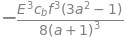

In [93]:
C_13_sol

$ C_{1,5}^{s,III}$ =

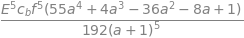

In [94]:
C_15_sol

$ C_{2,2}^{s,III}$ =

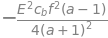

In [95]:
C_22_sol

$ C_{2,4}^{s,III}$ =

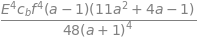

In [96]:
C_24_sol

$ C_{2,6}^{s,III}$ =

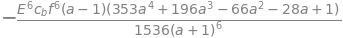

In [97]:
C_26_sol

$ C_{3,3}^{s,III}$ =

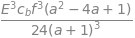

In [98]:
C_33_sol

$ C_{3,5}^{s,III}$ =

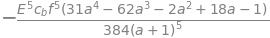

In [99]:
C_35_sol

$ C_{4,4}^{s,III}$ =

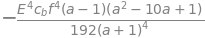

In [100]:
C_44_sol

$ C_{4,6}^{s,III}$ =

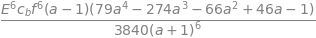

In [101]:
C_46_sol

$ C_{5}^{s,III}$ =

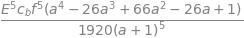

In [102]:
C_5_sol

$ C_{6}^{s,III}$ =

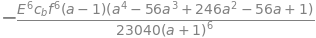

In [103]:
C_6_sol

## <ins>5. Determining the Models for Current</ins>

#### Defining Variable Substitutions and Current Equation

I_generalForm =


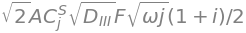

In [104]:
#Defining New Variables
F,A,R,T,D_III,j,C_T, D_0, δ = sp.symbols('F A R T D_III j C_j^S D_0 δ',real=True) #C_T is the temporary surface concentration ratio w/ respect to C_0

#Defining Expressions to Substitute In
D_III_expr = D_0 * (1+δ)
f_expr = F/(R*T)
a_expr = 1 + δ
I_expr = F * A * (D_III*one_half)**(one_half) * ((1 + sp.I) * (j * w)**(one_half)) * C_T
I_expr = sp.collect(I_expr, j * w)
print("I_generalForm =")
I_expr

where $C_j^S$ represents the temporary placeholder (C_T) for a substituted concentration coefficient.

$ \text{First Harmonic Current } \widetilde{I}_{1} $

I_1 =


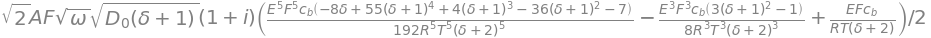

In [105]:
#Substitutions for f
C_11_sol_sub = C_11_sol.subs(f,f_expr)
C_13_sol_sub = C_13_sol.subs(f,f_expr)
C_15_sol_sub = C_15_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_1 = I_expr.subs({C_T: C_11_sol_sub+C_13_sol_sub+C_15_sol_sub, j: 1,D_III: D_III_expr,a:a_expr})

print("I_1 =")
I_1

$ \text{Second Harmonic Current } \widetilde{I}_{2} $

I_2 =


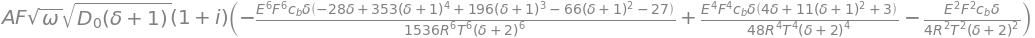

In [106]:
#Substitutions for f
C_22_sol_sub = C_22_sol.subs(f,f_expr)
C_24_sol_sub = C_24_sol.subs(f,f_expr)
C_26_sol_sub = C_26_sol.subs(f,f_expr)

#Substitutions of 'C_T' and other variable expressions into Current Equation
I_2 = I_expr.subs({C_T: C_22_sol_sub+C_24_sol_sub+C_26_sol_sub, j: 2,D_III: D_III_expr, a:a_expr})

print("I_2 =")
I_2